# SparkCity Weather Feature — Day 3

**Owner:** Matthew Baise  
**Focus:** Time-series analysis, rolling statistics, feature engineering, trends, and geographic weather aggregates

## Purpose

This notebook transforms validated SparkCity weather readings into hourly and daily analytical features. These outputs can support dashboards and cross-team analysis with traffic and energy data.

In [1]:
from pathlib import Path

from pyspark.sql import DataFrame, SparkSession, Window
from pyspark.sql import functions as F

from sparkcityx.data_quality import validate_dataframe
from sparkcityx.loaders import load_dataset

In [2]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SparkCity-Weather-Day3")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print(f"Spark master: {spark.sparkContext.master}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/14 19:23:46 WARN Utils: Your hostname, Zipcoders-MacBook-8.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.142 instead (on interface en0)
26/09/14 19:23:46 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/14 19:23:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0
Spark master: local[*]


In [3]:
weather_path = Path("../data/raw/weather_data.parquet")

if not weather_path.exists():
    weather_path = Path("data/raw/weather_data.parquet")

weather_df = load_dataset(spark, weather_path).cache()
weather_report = validate_dataframe(weather_df, "weather")

print(f"Records: {weather_df.count():,}")
print(f"Stations: {weather_df.select('station_id').distinct().count():,}")
print(f"Valid source: {weather_report['valid']}")

26/09/14 19:23:53 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Records: 36,000
Stations: 1,200
Valid source: True


In [4]:
weather_time_df = (
    weather_df
    .withColumn("reading_date", F.to_date("timestamp"))
    .withColumn("year", F.year("timestamp"))
    .withColumn("month", F.month("timestamp"))
    .withColumn("day_of_week", F.dayofweek("timestamp"))
    .withColumn("hour", F.hour("timestamp"))
    .withColumn("hour_timestamp", F.date_trunc("hour", "timestamp"))
)

In [5]:
hourly_weather_df = (
    weather_time_df
    .groupBy("hour_timestamp")
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.avg("humidity").alias("avg_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.max("wind_speed").alias("max_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
        F.max("precipitation").alias("max_precipitation"),
        F.avg("pressure").alias("avg_pressure"),
        F.count("*").alias("reading_count"),
    )
    .orderBy("hour_timestamp")
)

hourly_weather_df.show(10, truncate=False)

+-------------------+------------------+-----------------+------------------+--------------+-------------------+-----------------+------------------+-------------+
|hour_timestamp     |avg_temperature   |avg_humidity     |avg_wind_speed    |max_wind_speed|avg_precipitation  |max_precipitation|avg_pressure      |reading_count|
+-------------------+------------------+-----------------+------------------+--------------+-------------------+-----------------+------------------+-------------+
|2025-01-01 00:00:00|51.32             |62.185           |23.195            |23.83         |0.3055             |0.371            |1011.925          |2            |
|2025-01-01 01:00:00|52.105000000000004|58.81            |11.190000000000001|13.31         |0.0945             |0.126            |1009.5799999999999|2            |
|2025-01-01 02:00:00|52.205            |59.125           |12.53             |15.79         |0.0685             |0.137            |1012.5250000000001|2            |
|2025-01-01 03:0

In [6]:
daily_weather_df = (
    weather_time_df
    .groupBy("reading_date")
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.min("temperature").alias("min_temperature"),
        F.max("temperature").alias("max_temperature"),
        F.avg("humidity").alias("avg_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.max("wind_speed").alias("max_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
        F.max("precipitation").alias("max_precipitation"),
        F.avg("pressure").alias("avg_pressure"),
        F.count("*").alias("reading_count"),
    )
    .orderBy("reading_date")
)

daily_weather_df.show(10, truncate=False)

+------------+------------------+---------------+---------------+------------------+------------------+--------------+-------------------+-----------------+------------------+-------------+
|reading_date|avg_temperature   |min_temperature|max_temperature|avg_humidity      |avg_wind_speed    |max_wind_speed|avg_precipitation  |max_precipitation|avg_pressure      |reading_count|
+------------+------------------+---------------+---------------+------------------+------------------+--------------+-------------------+-----------------+------------------+-------------+
|2025-01-01  |55.999166666666675|49.61          |61.76          |55.06229166666666 |14.219375000000005|23.83         |0.11916666666666666|0.455            |1011.3791666666663|48           |
|2025-01-02  |63.52416666666668 |58.21          |68.39          |50.135            |10.464375         |21.95         |0.11770833333333332|0.706            |1011.4662499999998|48           |
|2025-01-03  |67.03770833333333 |63.9           |7

## 1. Recurring Weather Patterns

Weather readings are grouped by hour, weekday, and month to reveal recurring temporal patterns.

In [7]:
hour_of_day_pattern_df = (
    weather_time_df
    .groupBy("hour")
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.avg("humidity").alias("avg_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
        F.count("*").alias("reading_count"),
    )
    .orderBy("hour")
)

hour_of_day_pattern_df.show(24, truncate=False)

+----+------------------+------------------+------------------+-------------------+-------------+
|hour|avg_temperature   |avg_humidity      |avg_wind_speed    |avg_precipitation  |reading_count|
+----+------------------+------------------+------------------+-------------------+-------------+
|0   |52.05281999999996 |57.884680000000074|13.723306666666678|0.11639733333333341|1500         |
|1   |52.09417999999998 |57.815413333333346|13.780146666666685|0.12016733333333332|1500         |
|2   |52.05921333333336 |58.03982000000006 |13.648206666666644|0.11475399999999991|1500         |
|3   |52.08801999999996 |57.87038666666678 |13.907086666666656|0.11565266666666649|1500         |
|4   |51.965653333333385|57.8691666666666  |13.945759999999995|0.11712266666666679|1500         |
|5   |52.03460666666659 |57.92417333333337 |13.859346666666653|0.12290000000000022|1500         |
|6   |52.09998          |57.80517333333338 |13.937900000000012|0.11491200000000015|1500         |
|7   |52.17495999999

In [8]:
weekday_pattern_df = (
    weather_time_df
    .groupBy("day_of_week")
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.avg("humidity").alias("avg_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
    )
    .orderBy("day_of_week")
)

weekday_pattern_df.show(7, truncate=False)

+-----------+------------------+------------------+------------------+-------------------+
|day_of_week|avg_temperature   |avg_humidity      |avg_wind_speed    |avg_precipitation  |
+-----------+------------------+------------------+------------------+-------------------+
|1          |52.09667834890963 |57.936538161993454|13.782673286604375|0.118550623052959  |
|2          |52.065426401869175|57.896320093458   |13.790576323987578|0.11934696261682234|
|3          |51.95985202492207 |57.955075934579384|13.825671728971919|0.11795658099688443|
|4          |51.92881751543223 |57.98266203703715 |13.753269675925905|0.11844791666666671|
|5          |52.08336059190053 |57.89621105919003 |13.842585669781934|0.11850097352024903|
|6          |52.172830996884755|57.811156542056125|13.810845015576316|0.11732749221183773|
|7          |52.09369937694712 |57.8349980529594  |13.89642912772585 |0.1162198208722742 |
+-----------+------------------+------------------+------------------+-------------------+

In [9]:
monthly_pattern_df = (
    weather_time_df
    .groupBy("month")
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.min("temperature").alias("min_temperature"),
        F.max("temperature").alias("max_temperature"),
        F.avg("humidity").alias("avg_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
    )
    .orderBy("month")
)

monthly_pattern_df.show(12, truncate=False)

+-----+------------------+---------------+---------------+------------------+------------------+-------------------+
|month|avg_temperature   |min_temperature|max_temperature|avg_humidity      |avg_wind_speed    |avg_precipitation  |
+-----+------------------+---------------+---------------+------------------+------------------+-------------------+
|1    |53.8042098577237  |33.02          |70.93          |56.572098577235906|13.830975609756063|0.12032469512195124|
|2    |50.14629092261903 |33.02          |70.98          |59.38149925595235 |13.80440848214287 |0.11963095238095231|
|3    |53.664183467742035|33.07          |70.95          |56.66674059139794 |13.90463709677418 |0.12278360215053742|
|4    |50.78748611111112 |33.01          |70.97          |58.82315624999998 |13.79312152777776 |0.11403159722222214|
|5    |52.117335349462444|33.09          |70.95          |57.86730510752687 |13.778807123655918|0.1164751344086019 |
|6    |52.98075694444442 |33.08          |70.88          |57.158

## 2. Rolling Statistics, Lags, and Trends

Citywide hourly aggregates are used because individual stations in this synthetic dataset report only once every 600 hours.

In [10]:
hour_order_window = Window.orderBy("hour_timestamp")
rolling_24_hour_window = hour_order_window.rowsBetween(-23, 0)

hourly_features_df = (
    hourly_weather_df
    .withColumn(
        "temperature_24h_mean",
        F.avg("avg_temperature").over(rolling_24_hour_window),
    )
    .withColumn(
        "temperature_24h_stddev",
        F.stddev("avg_temperature").over(rolling_24_hour_window),
    )
    .withColumn(
        "humidity_24h_mean",
        F.avg("avg_humidity").over(rolling_24_hour_window),
    )
    .withColumn(
        "wind_speed_24h_max",
        F.max("max_wind_speed").over(rolling_24_hour_window),
    )
    .withColumn(
        "temperature_lag_1h",
        F.lag("avg_temperature", 1).over(hour_order_window),
    )
    .withColumn(
        "temperature_lag_24h",
        F.lag("avg_temperature", 24).over(hour_order_window),
    )
    .withColumn(
        "temperature_change_1h",
        F.col("avg_temperature") - F.col("temperature_lag_1h"),
    )
    .withColumn(
        "temperature_change_24h",
        F.col("avg_temperature") - F.col("temperature_lag_24h"),
    )
    .withColumn(
        "temperature_trend",
        F.when(
            F.col("temperature_lag_24h").isNull(),
            F.lit("INSUFFICIENT_HISTORY"),
        )
        .when(
            F.col("avg_temperature") > F.col("temperature_lag_24h"),
            F.lit("WARMING"),
        )
        .when(
            F.col("avg_temperature") < F.col("temperature_lag_24h"),
            F.lit("COOLING"),
        )
        .otherwise(F.lit("STABLE")),
    )
)

hourly_features_df.show(30, truncate=False)

26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 1

+-------------------+------------------+------------------+------------------+--------------+-------------------+-----------------+------------------+-------------+--------------------+----------------------+------------------+------------------+------------------+-------------------+---------------------+----------------------+--------------------+
|hour_timestamp     |avg_temperature   |avg_humidity      |avg_wind_speed    |max_wind_speed|avg_precipitation  |max_precipitation|avg_pressure      |reading_count|temperature_24h_mean|temperature_24h_stddev|humidity_24h_mean |wind_speed_24h_max|temperature_lag_1h|temperature_lag_24h|temperature_change_1h|temperature_change_24h|temperature_trend   |
+-------------------+------------------+------------------+------------------+--------------+-------------------+-----------------+------------------+-------------+--------------------+----------------------+------------------+------------------+------------------+-------------------+-----------

26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:56 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


In [11]:
daily_order_window = Window.orderBy("reading_date")
rolling_7_day_window = daily_order_window.rowsBetween(-6, 0)
rolling_30_day_window = daily_order_window.rowsBetween(-29, 0)

daily_features_df = (
    daily_weather_df
    .withColumn(
        "temperature_7d_mean",
        F.avg("avg_temperature").over(rolling_7_day_window),
    )
    .withColumn(
        "temperature_30d_mean",
        F.avg("avg_temperature").over(rolling_30_day_window),
    )
    .withColumn(
        "humidity_7d_mean",
        F.avg("avg_humidity").over(rolling_7_day_window),
    )
    .withColumn(
        "wind_speed_7d_max",
        F.max("max_wind_speed").over(rolling_7_day_window),
    )
    .withColumn(
        "temperature_lag_1d",
        F.lag("avg_temperature", 1).over(daily_order_window),
    )
    .withColumn(
        "temperature_change_1d",
        F.col("avg_temperature") - F.col("temperature_lag_1d"),
    )
)

daily_features_df.show(10, truncate=False)

26/09/14 19:23:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:23:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 1

+------------+------------------+---------------+---------------+------------------+------------------+--------------+-------------------+-----------------+------------------+-------------+-------------------+--------------------+------------------+-----------------+------------------+---------------------+
|reading_date|avg_temperature   |min_temperature|max_temperature|avg_humidity      |avg_wind_speed    |max_wind_speed|avg_precipitation  |max_precipitation|avg_pressure      |reading_count|temperature_7d_mean|temperature_30d_mean|humidity_7d_mean  |wind_speed_7d_max|temperature_lag_1d|temperature_change_1d|
+------------+------------------+---------------+---------------+------------------+------------------+--------------+-------------------+-----------------+------------------+-------------+-------------------+--------------------+------------------+-----------------+------------------+---------------------+
|2025-01-01  |55.999166666666675|49.61          |61.76          |55.06229

## 3. Weather Interaction and Cyclical Features

Dataset-relative thresholds classify unusual wind and precipitation without assuming undocumented measurement units. Wind direction, hour, and month are encoded cyclically because their endpoints wrap around.

In [12]:
positive_precipitation_df = weather_time_df.filter(
    F.col("precipitation") > 0
)

precipitation_threshold = positive_precipitation_df.approxQuantile(
    "precipitation",
    [0.75],
    0.01,
)[0]

wind_threshold = weather_time_df.approxQuantile(
    "wind_speed",
    [0.75],
    0.01,
)[0]

print(f"High-precipitation threshold: {precipitation_threshold:.3f}")
print(f"High-wind threshold: {wind_threshold:.3f}")

High-precipitation threshold: 0.251
High-wind threshold: 17.670


In [13]:
weather_feature_df = (
    weather_time_df
    .withColumn(
        "is_precipitating",
        F.col("precipitation") > 0,
    )
    .withColumn(
        "is_high_precipitation",
        F.col("precipitation") >= precipitation_threshold,
    )
    .withColumn(
        "is_high_wind",
        F.col("wind_speed") >= wind_threshold,
    )
    .withColumn(
        "temperature_humidity_interaction",
        F.col("temperature") * F.col("humidity"),
    )
    .withColumn(
        "wind_direction_sin",
        F.sin(F.radians("wind_direction")),
    )
    .withColumn(
        "wind_direction_cos",
        F.cos(F.radians("wind_direction")),
    )
    .withColumn(
        "hour_sin",
        F.sin(2 * F.lit(3.141592653589793) * F.col("hour") / 24),
    )
    .withColumn(
        "hour_cos",
        F.cos(2 * F.lit(3.141592653589793) * F.col("hour") / 24),
    )
    .withColumn(
        "month_sin",
        F.sin(2 * F.lit(3.141592653589793) * F.col("month") / 12),
    )
    .withColumn(
        "month_cos",
        F.cos(2 * F.lit(3.141592653589793) * F.col("month") / 12),
    )
    .withColumn(
        "weather_condition",
        F.when(
            (F.col("precipitation") >= precipitation_threshold)
            & (F.col("wind_speed") >= wind_threshold),
            F.lit("WET_AND_WINDY"),
        )
        .when(
            F.col("precipitation") >= precipitation_threshold,
            F.lit("HIGH_PRECIPITATION"),
        )
        .when(
            F.col("wind_speed") >= wind_threshold,
            F.lit("HIGH_WIND"),
        )
        .when(
            F.col("precipitation") > 0,
            F.lit("LIGHT_PRECIPITATION"),
        )
        .otherwise(F.lit("DRY")),
    )
)

In [14]:
(
    weather_feature_df
    .groupBy("weather_condition")
    .count()
    .withColumn(
        "percentage",
        F.round(F.col("count") / weather_feature_df.count() * 100, 2),
    )
    .orderBy(F.desc("count"))
    .show(truncate=False)
)

+-------------------+-----+----------+
|weather_condition  |count|percentage|
+-------------------+-----+----------+
|LIGHT_PRECIPITATION|13253|36.81     |
|DRY                |8837 |24.55     |
|HIGH_WIND          |7738 |21.49     |
|HIGH_PRECIPITATION |4591 |12.75     |
|WET_AND_WINDY      |1581 |4.39      |
+-------------------+-----+----------+



In [15]:
weather_feature_df.select(
    "station_id",
    "timestamp",
    "temperature",
    "humidity",
    "wind_speed",
    "precipitation",
    "weather_condition",
    "wind_direction_sin",
    "wind_direction_cos",
    "hour_sin",
    "hour_cos",
).show(10, truncate=False)

+----------+-------------------+-----------+--------+----------+-------------+-------------------+---------------------+--------------------+-------------------+------------------+
|station_id|timestamp          |temperature|humidity|wind_speed|precipitation|weather_condition  |wind_direction_sin   |wind_direction_cos  |hour_sin           |hour_cos          |
+----------+-------------------+-----------+--------+----------+-------------+-------------------+---------------------+--------------------+-------------------+------------------+
|WTH-0001  |2025-01-01 00:00:00|51.69      |62.77   |22.56     |0.371        |WET_AND_WINDY      |-0.9563047559630355  |0.2923717047227367  |0.0                |1.0               |
|WTH-0002  |2025-01-01 00:30:00|50.95      |61.6    |23.83     |0.24         |HIGH_WIND          |-0.5684182642193029  |0.82273973825379    |0.0                |1.0               |
|WTH-0003  |2025-01-01 01:00:00|49.61      |59.22   |13.31     |0.063        |LIGHT_PRECIPITATI

## 4. Zone-Level Weather Features

Geographic boundary matching assigns each weather reading to one city zone. If zone boundaries overlap, the smallest matching zone is selected deterministically.

In [16]:
zones_path = Path("../data/reference/city_zones.csv")

if not zones_path.exists():
    zones_path = Path("data/reference/city_zones.csv")

zones_df = load_dataset(spark, zones_path)
print(f"Zones loaded: {zones_df.count():,}")

Zones loaded: 5


In [17]:
weather_alias = weather_feature_df.alias("weather")
zone_alias = F.broadcast(zones_df).alias("zone")

zone_condition = (
    F.col("weather.location_lat").between(
        F.col("zone.lat_min"),
        F.col("zone.lat_max"),
    )
    & F.col("weather.location_lon").between(
        F.col("zone.lon_min"),
        F.col("zone.lon_max"),
    )
)

zone_candidates_df = (
    weather_alias
    .join(zone_alias, zone_condition, "left")
    .select(
        "weather.*",
        F.col("zone.zone_id").alias("zone_id"),
        F.col("zone.zone_name").alias("zone_name"),
        F.col("zone.zone_type").alias("zone_type"),
        (
            (F.col("zone.lat_max") - F.col("zone.lat_min"))
            * (F.col("zone.lon_max") - F.col("zone.lon_min"))
        ).alias("_zone_area"),
    )
)

zone_rank_window = Window.partitionBy(
    "station_id",
    "timestamp",
).orderBy(
    F.col("_zone_area").asc_nulls_last(),
    F.col("zone_id").asc_nulls_last(),
)

weather_zoned_df = (
    zone_candidates_df
    .withColumn(
        "_zone_rank",
        F.row_number().over(zone_rank_window),
    )
    .filter(F.col("_zone_rank") == 1)
    .drop("_zone_area", "_zone_rank")
)

In [18]:
weather_zoned_df.agg(
    F.count("*").alias("output_rows"),
    F.sum(
        F.when(F.col("zone_id").isNotNull(), 1).otherwise(0)
    ).alias("mapped_rows"),
    F.sum(
        F.when(F.col("zone_id").isNull(), 1).otherwise(0)
    ).alias("unmapped_rows"),
).show(truncate=False)

+-----------+-----------+-------------+
|output_rows|mapped_rows|unmapped_rows|
+-----------+-----------+-------------+
|36000      |1217       |34783        |
+-----------+-----------+-------------+



In [19]:
zone_hourly_weather_df = (
    weather_zoned_df
    .filter(F.col("zone_id").isNotNull())
    .groupBy(
        "zone_id",
        "zone_name",
        "zone_type",
        "hour_timestamp",
    )
    .agg(
        F.avg("temperature").alias("avg_temperature"),
        F.avg("humidity").alias("avg_humidity"),
        F.avg("wind_speed").alias("avg_wind_speed"),
        F.max("wind_speed").alias("max_wind_speed"),
        F.avg("precipitation").alias("avg_precipitation"),
        F.max("precipitation").alias("max_precipitation"),
        F.avg("pressure").alias("avg_pressure"),
        F.sum(
            F.when(F.col("is_high_wind"), 1).otherwise(0)
        ).alias("high_wind_readings"),
        F.sum(
            F.when(
                F.col("is_high_precipitation"),
                1,
            ).otherwise(0)
        ).alias("high_precipitation_readings"),
        F.count("*").alias("weather_readings"),
    )
    .orderBy("zone_id", "hour_timestamp")
)

zone_hourly_weather_df.show(20, truncate=False)

+--------+------------------+----------+-------------------+------------------+------------------+------------------+--------------+-------------------+-----------------+------------------+------------------+---------------------------+----------------+
|zone_id |zone_name         |zone_type |hour_timestamp     |avg_temperature   |avg_humidity      |avg_wind_speed    |max_wind_speed|avg_precipitation  |max_precipitation|avg_pressure      |high_wind_readings|high_precipitation_readings|weather_readings|
+--------+------------------+----------+-------------------+------------------+------------------+------------------+--------------+-------------------+-----------------+------------------+------------------+---------------------------+----------------+
|ZONE_001|Downtown Manhattan|commercial|2025-01-28 21:00:00|61.18             |48.1              |19.43             |19.43         |0.0                |0.0              |1003.0            |1                 |0                          |1 

In [20]:
print("CROSS-TEAM WEATHER JOIN CONTRACT")
print("=" * 50)
print("Join keys: zone_id + hour_timestamp")
print("Granularity: one row per mapped zone per hour")
print("Temperature unit: unconfirmed")
print("Wind-speed unit: unconfirmed")
print("Precipitation unit: unconfirmed")
print("Pressure unit: unconfirmed")

CROSS-TEAM WEATHER JOIN CONTRACT
Join keys: zone_id + hour_timestamp
Granularity: one row per mapped zone per hour
Temperature unit: unconfirmed
Wind-speed unit: unconfirmed
Precipitation unit: unconfirmed
Pressure unit: unconfirmed


## 5. Correlation Study

The correlation matrix measures relationships within the weather dataset. Cross-dataset energy and traffic correlations can use the zone-hour join contract created above.

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

correlation_columns = [
    "temperature",
    "humidity",
    "wind_speed",
    "precipitation",
    "pressure",
]

correlation_values = []

for left_column in correlation_columns:
    row = []

    for right_column in correlation_columns:
        row.append(
            weather_df.stat.corr(
                left_column,
                right_column,
            )
        )

    correlation_values.append(row)

correlation_matrix = pd.DataFrame(
    correlation_values,
    index=correlation_columns,
    columns=correlation_columns,
)

correlation_matrix.round(3)

,temperature,humidity,wind_speed,precipitation,pressure
temperature,1.000,-0.936,0.008,0.001,0.000
humidity,-0.936,1.000,-0.008,-0.001,0.003
wind_speed,0.008,-0.008,1.000,0.007,-0.006
precipitation,0.001,-0.001,0.007,1.000,-0.001
pressure,0.000,0.003,-0.006,-0.001,1.000


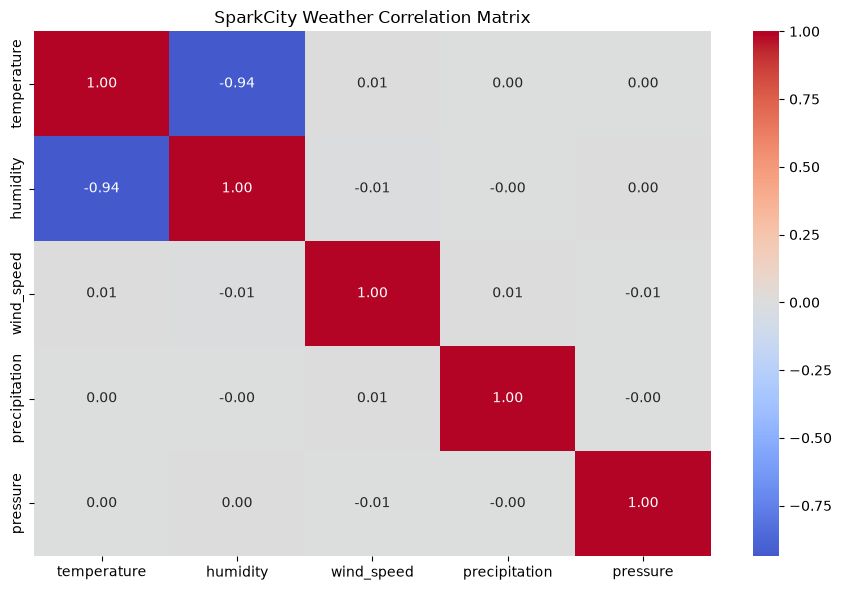

In [22]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)

plt.title("SparkCity Weather Correlation Matrix")
plt.tight_layout()
plt.show()

In [23]:
hourly_analysis_df = (
    hourly_features_df
    .withColumn(
        "temperature_deviation",
        F.col("avg_temperature")
        - F.col("temperature_24h_mean"),
    )
    .withColumn(
        "temperature_pattern_anomaly",
        F.when(
            F.col("temperature_24h_stddev").isNotNull()
            & (
                F.abs(F.col("temperature_deviation"))
                > 2 * F.col("temperature_24h_stddev")
            ),
            True,
        ).otherwise(False),
    )
)

hourly_analysis_df.groupBy(
    "temperature_trend"
).count().orderBy(F.desc("count")).show()

print(
    "Temperature pattern anomalies:",
    hourly_analysis_df.filter(
        F.col("temperature_pattern_anomaly")
    ).count(),
)

26/09/14 19:24:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:01 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 1

+--------------------+-----+
|   temperature_trend|count|
+--------------------+-----+
|             COOLING| 8993|
|             WARMING| 8975|
|INSUFFICIENT_HISTORY|   24|
|              STABLE|    6|
+--------------------+-----+



26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Temperature pattern anomalies: 1740


26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 1

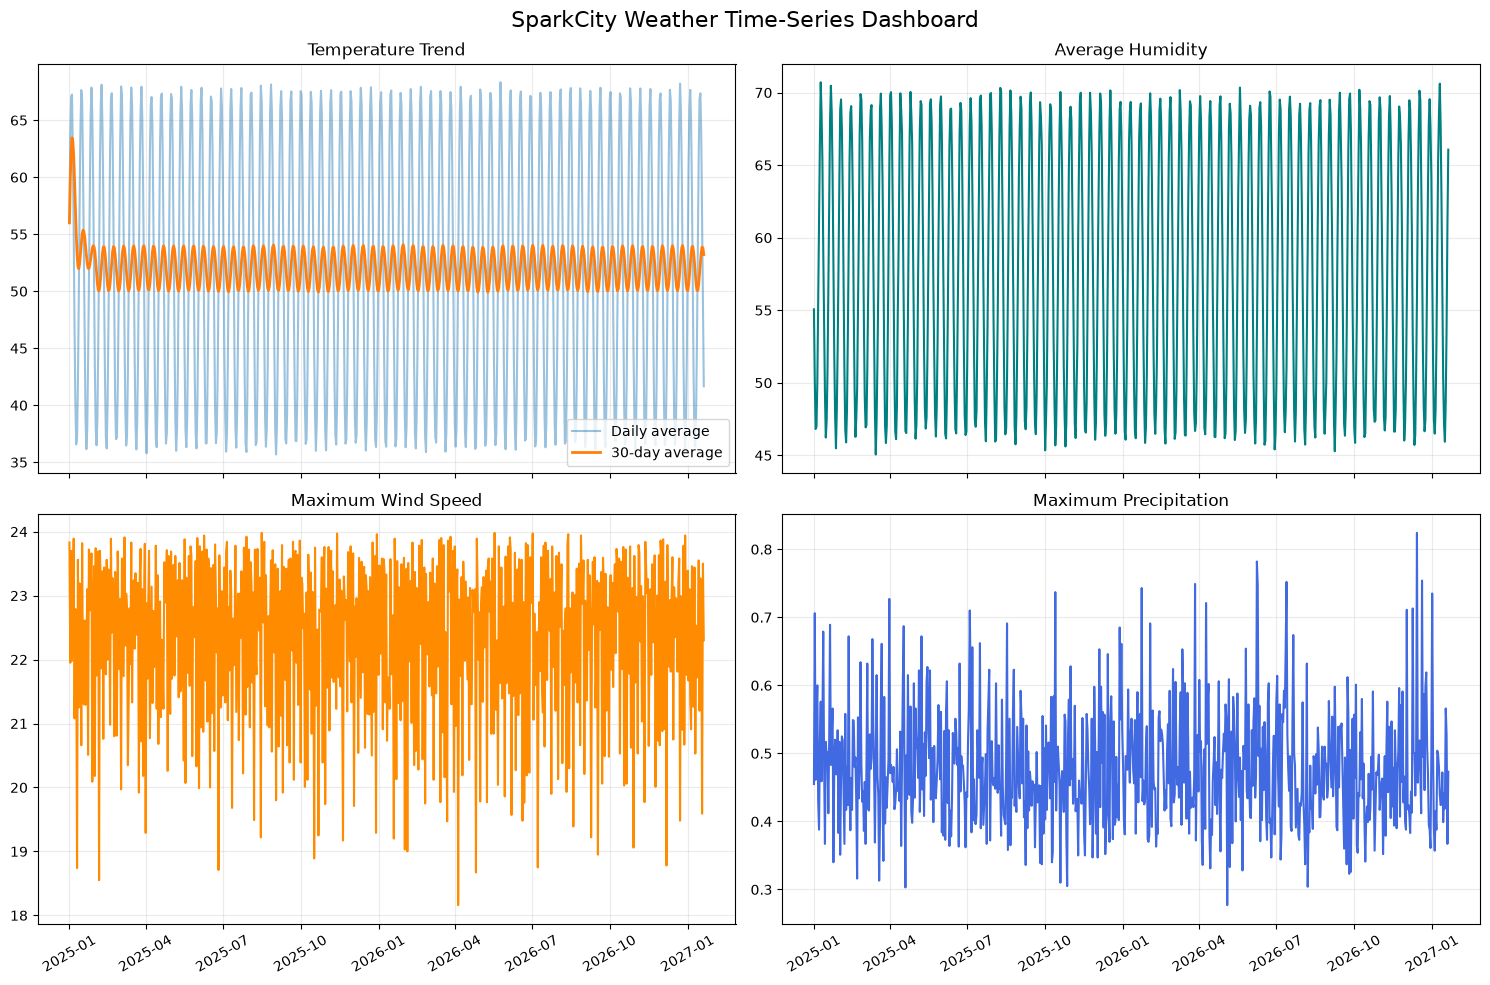

In [24]:
daily_plot_df = (
    daily_features_df
    .orderBy("reading_date")
    .toPandas()
)

daily_plot_df["reading_date"] = pd.to_datetime(
    daily_plot_df["reading_date"]
)

figure, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    sharex=True,
)

axes[0, 0].plot(
    daily_plot_df["reading_date"],
    daily_plot_df["avg_temperature"],
    alpha=0.45,
    label="Daily average",
)
axes[0, 0].plot(
    daily_plot_df["reading_date"],
    daily_plot_df["temperature_30d_mean"],
    linewidth=2,
    label="30-day average",
)
axes[0, 0].set_title("Temperature Trend")
axes[0, 0].legend()

axes[0, 1].plot(
    daily_plot_df["reading_date"],
    daily_plot_df["avg_humidity"],
    color="teal",
)
axes[0, 1].set_title("Average Humidity")

axes[1, 0].plot(
    daily_plot_df["reading_date"],
    daily_plot_df["max_wind_speed"],
    color="darkorange",
)
axes[1, 0].set_title("Maximum Wind Speed")

axes[1, 1].plot(
    daily_plot_df["reading_date"],
    daily_plot_df["max_precipitation"],
    color="royalblue",
)
axes[1, 1].set_title("Maximum Precipitation")

for axis in axes.flat:
    axis.grid(alpha=0.25)
    axis.tick_params(axis="x", rotation=30)

figure.suptitle(
    "SparkCity Weather Time-Series Dashboard",
    fontsize=16,
)
plt.tight_layout()
plt.show()

In [25]:
source_count = weather_df.count()
hourly_count = hourly_features_df.count()

mapped_rows = weather_zoned_df.filter(
    F.col("zone_id").isNotNull()
).count()

unmapped_rows = weather_zoned_df.filter(
    F.col("zone_id").isNull()
).count()

pattern_anomalies = hourly_analysis_df.filter(
    F.col("temperature_pattern_anomaly")
).count()

mapping_percentage = (
    mapped_rows / source_count * 100
    if source_count
    else 0
)

anomaly_percentage = (
    pattern_anomalies / hourly_count * 100
    if hourly_count
    else 0
)

26/09/14 19:24:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 19:24:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/14 1

In [26]:


print("DAY 3 WEATHER ANALYTICS SUMMARY")
print("=" * 50)
print(f"Source records: {weather_df.count():,}")
print(f"Hourly feature rows: {hourly_features_df.count():,}")
print(f"Daily feature rows: {daily_features_df.count():,}")
print(f"Mapped weather rows: {mapped_rows:,}")
print(f"Unmapped weather rows: {unmapped_rows:,}")
print(f"Zone-hour feature rows: {zone_hourly_weather_df.count():,}")
print(f"Temperature pattern anomalies: {pattern_anomalies:,}")
print("Cross-team join keys: zone_id + hour_timestamp")

DAY 3 WEATHER ANALYTICS SUMMARY
Source records: 36,000
Hourly feature rows: 17,998
Daily feature rows: 750
Mapped weather rows: 1,217
Unmapped weather rows: 34,783
Zone-hour feature rows: 785
Temperature pattern anomalies: 1,740
Cross-team join keys: zone_id + hour_timestamp


In [27]:
weather_df.unpersist()
spark.stop()
print("Spark session stopped successfully.")

Spark session stopped successfully.


## 6. Findings and Integration Limitations

- The weather source contains 36,000 valid readings across 1,200 stations.
- Hourly and daily features were generated without assuming undocumented measurement units.
- Temperature anomaly flags identify deviations from the rolling 24-hour pattern; they do not prove that a reading is invalid.
- Only a small portion of weather coordinates fall within the supplied city-zone boundaries.
- Unmapped records are preserved instead of being assigned to an incorrect zone.
- Cross-team joins using `zone_id` and `hour_timestamp` must currently be limited to mapped records.
- The team should either expand the zone reference coverage or agree upon an approved nearest-zone matching rule.

In [28]:
print(f"Zone mapping coverage: {mapping_percentage:.2f}%")
print(f"Temperature anomaly rate: {anomaly_percentage:.2f}%")

Zone mapping coverage: 3.38%
Temperature anomaly rate: 9.67%
